# Multi-Armed Bandit Practice

- 이름: 이영훈
- 학번: 2632036005
- 과목명: 인공지능특강
- 주제: Multi-Armed Bandit

## 1. 실습 목표

이번 실습에서는 Multi-Armed Bandit 문제를 통해 epsilon-greedy 방식이 어떻게 동작하는지 확인한다.
또한 단일 실행, 반복 평균 실행, non-stationary 환경에서의 차이를 비교한다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2. 실습 1: a_bandit.py

기본적인 stationary multi-armed bandit 환경에서 epsilon-greedy 정책을 사용하여
보상이 높은 arm을 점차 찾아가는 과정을 확인한다.

### 2-1. 실행 결과 예시 1

동일한 코드와 하이퍼파라미터(`steps = 2000`, `epsilon = 0.1`)로 첫 번째 실험을 수행하였다.
이때의 누적 보상 및 평균 승률 그래프는 아래와 같다.

각 슬롯머신의 승률: [0.80370829 0.2059456  0.38629083 0.70813536 0.39784905 0.15265389
 0.89607081 0.69212062 0.33631521 0.03324947]
가장 좋은 슬롯머신의 승률: 0.8960708058514644

누적 보상: 1673
최종 승률: 0.8365


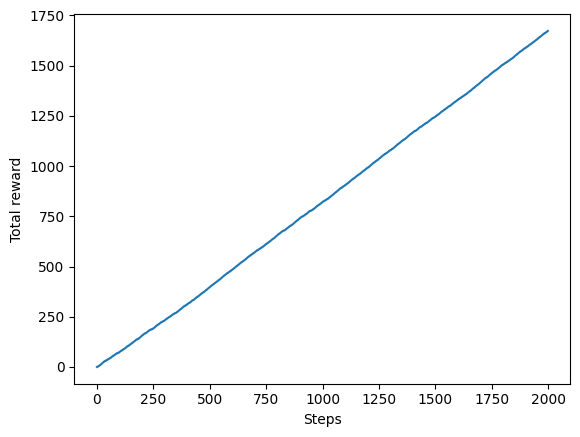

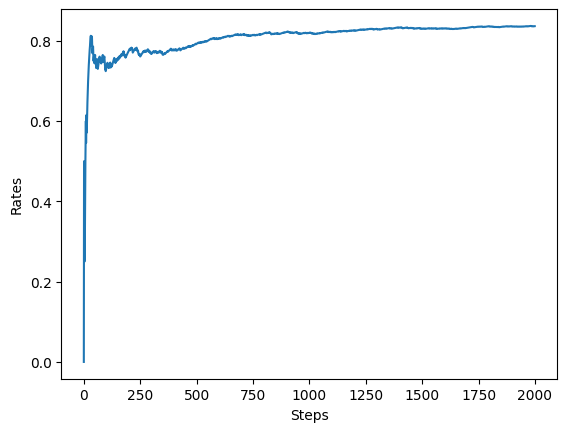

In [20]:
import numpy as np
import matplotlib.pyplot as plt

class Bandit:
    def __init__(self, arms=10):  # arms = 슬롯머신 대수
        self.rates = np.random.rand(arms)  # 슬롯머신 각각의 승률 설정(무작위)
        print("각 슬롯머신의 승률:", self.rates)
        print("가장 좋은 슬롯머신의 승률:", max(self.rates))
        print()

    def play(self, arm):
        rate = self.rates[arm]
        if rate > np.random.rand():
            return 1
        else:
            return 0


class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon  # 무작위로 행동할 확률(탐색 확률)
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    # 슬롯머신의 가치 추정
    def update(self, action, reward):
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    # 행동 선택(ε-탐욕 정책)
    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))  # 무작위 행동 선택
        return np.argmax(self.Qs)  # 탐욕 행동 선택


if __name__ == '__main__':
    steps = 2000
    epsilon = 0.1

    bandit = Bandit()
    agent = Agent(epsilon)
    total_reward = 0
    total_rewards = []  # 보상 합
    rates = []          # 승률

    for step in range(steps):
        action = agent.get_action()   # 행동 선택
        reward = bandit.play(action)  # 실제로 플레이하고 보상을 받음
        agent.update(action, reward)  # 행동과 보상을 통해 학습
        total_reward += reward

        total_rewards.append(total_reward)       # 현재까지의 보상 합 저장
        rates.append(total_reward / (step + 1))  # 현재까지의 승률 저장

    print("누적 보상:", total_reward)
    print("최종 승률:", rates[-1])

    # [그림 1-12] 스텝별 보상 총합
    plt.ylabel('Total reward')
    plt.xlabel('Steps')
    plt.plot(total_rewards)
    plt.show()

    # [그림 1-13] 스텝별 승률
    plt.ylabel('Rates')
    plt.xlabel('Steps')
    plt.plot(rates)
    plt.show()


### 2-2. 실행 결과 예시 2

동일한 코드와 하이퍼파라미터(`steps = 2000`, `epsilon = 0.1`)로 두 번째 실험을 수행하였다.
이때의 누적 보상 및 평균 승률 그래프는 아래와 같다.

각 슬롯머신의 승률: [0.86094852 0.58246357 0.74624198 0.19792664 0.50246361 0.70619887
 0.72096119 0.59973991 0.07212861 0.71579338]
가장 좋은 슬롯머신의 승률: 0.8609485206025181

누적 보상: 1649
최종 승률: 0.8245


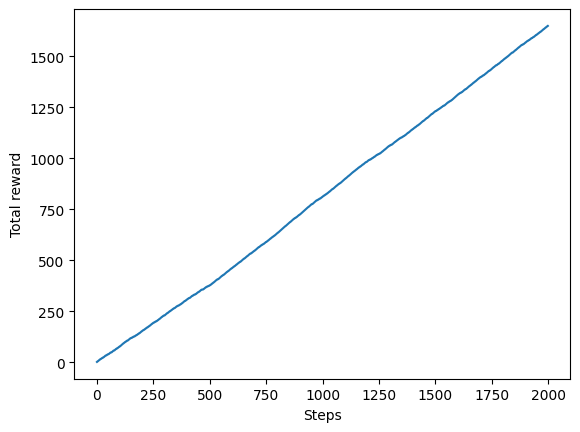

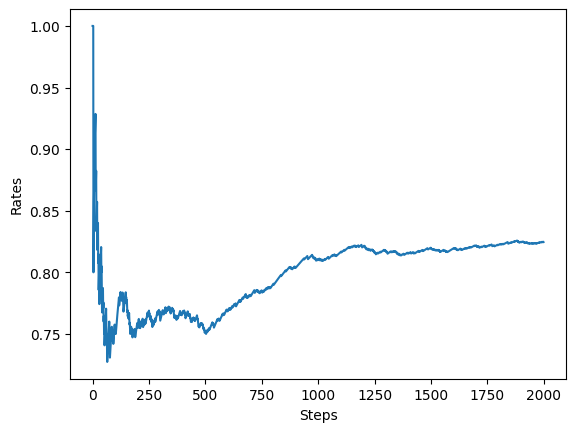

In [19]:
import numpy as np
import matplotlib.pyplot as plt

class Bandit:
    def __init__(self, arms=10):  # arms = 슬롯머신 대수
        self.rates = np.random.rand(arms)  # 슬롯머신 각각의 승률 설정(무작위)
        print("각 슬롯머신의 승률:", self.rates)
        print("가장 좋은 슬롯머신의 승률:", max(self.rates))
        print()

    def play(self, arm):
        rate = self.rates[arm]
        if rate > np.random.rand():
            return 1
        else:
            return 0


class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon  # 무작위로 행동할 확률(탐색 확률)
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    # 슬롯머신의 가치 추정
    def update(self, action, reward):
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    # 행동 선택(ε-탐욕 정책)
    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))  # 무작위 행동 선택
        return np.argmax(self.Qs)  # 탐욕 행동 선택


if __name__ == '__main__':
    steps = 2000
    epsilon = 0.1

    bandit = Bandit()
    agent = Agent(epsilon)
    total_reward = 0
    total_rewards = []  # 보상 합
    rates = []          # 승률

    for step in range(steps):
        action = agent.get_action()   # 행동 선택
        reward = bandit.play(action)  # 실제로 플레이하고 보상을 받음
        agent.update(action, reward)  # 행동과 보상을 통해 학습
        total_reward += reward

        total_rewards.append(total_reward)       # 현재까지의 보상 합 저장
        rates.append(total_reward / (step + 1))  # 현재까지의 승률 저장

    print("누적 보상:", total_reward)
    print("최종 승률:", rates[-1])

    # [그림 1-12] 스텝별 보상 총합
    plt.ylabel('Total reward')
    plt.xlabel('Steps')
    plt.plot(total_rewards)
    plt.show()

    # [그림 1-13] 스텝별 승률
    plt.ylabel('Rates')
    plt.xlabel('Steps')
    plt.plot(rates)
    plt.show()


두 실험은 동일한 코드와 동일한 설정으로 수행되었음에도 불구하고,
누적 보상 곡선과 평균 승률, 최종 승률 값이 서로 다르게 나타났다.
이는 각 실행마다 슬롯머신의 실제 보상 확률이 무작위로 생성되며,
epsilon-greedy 정책 또한 탐색 과정에서 확률적 선택을 수행하기 때문이다.

즉, Multi-Armed Bandit 문제는 본질적으로 확률적 환경에 기반하므로,
동일한 코드로도 실행마다 다른 결과가 나타날 수 있다.
따라서 성능을 보다 신뢰성 있게 해석하기 위해서는 단일 실행 결과뿐 아니라
반복 실행을 통한 평균 성능도 함께 확인할 필요가 있다.

각 슬롯머신의 승률: [0.01956415 0.84574272 0.9760908  0.06975307 0.77994934 0.22738025
 0.48885869 0.93663463 0.98888307 0.17193299]
가장 좋은 슬롯머신의 승률: 0.9888830658320202

각 슬롯머신의 승률: [0.45630194 0.82383226 0.9390726  0.94774122 0.12849963 0.51395726
 0.64955025 0.07021123 0.06841794 0.10317917]
가장 좋은 슬롯머신의 승률: 0.9477412201598512

각 슬롯머신의 승률: [0.70365076 0.58876969 0.74577    0.82360596 0.36433261 0.15044007
 0.39181908 0.03263428 0.85022821 0.65436139]
가장 좋은 슬롯머신의 승률: 0.8502282062535289

각 슬롯머신의 승률: [0.94827596 0.57770717 0.63115143 0.73268848 0.61724694 0.46035802
 0.96122955 0.56988907 0.21114772 0.10185959]
가장 좋은 슬롯머신의 승률: 0.9612295545514896

각 슬롯머신의 승률: [0.66650034 0.73273604 0.26294191 0.95956697 0.34398833 0.27773692
 0.06721461 0.59377006 0.13834898 0.7890638 ]
가장 좋은 슬롯머신의 승률: 0.9595669650052943

각 슬롯머신의 승률: [2.16394591e-01 1.94656134e-01 9.76345805e-02 3.68879433e-01
 1.72644531e-01 7.05996649e-01 1.34503871e-04 5.66413794e-01
 8.41695036e-02 5.36919912e-01]
가장 좋은 슬롯머신의 승률: 0.70599664857

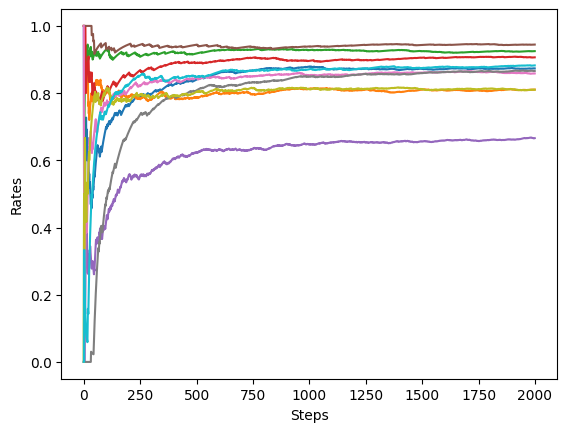

In [28]:
import numpy as np
import matplotlib.pyplot as plt

class Bandit:
    def __init__(self, arms=10):  # arms = 슬롯머신 대수
        self.rates = np.random.rand(arms)  # 슬롯머신 각각의 승률 설정(무작위)
        print("각 슬롯머신의 승률:", self.rates)
        print("가장 좋은 슬롯머신의 승률:", max(self.rates))
        print()

    def play(self, arm):
        rate = self.rates[arm]
        if rate > np.random.rand():
            return 1
        else:
            return 0


class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon  # 무작위로 행동할 확률(탐색 확률)
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    # 슬롯머신의 가치 추정
    def update(self, action, reward):
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    # 행동 선택(ε-탐욕 정책)
    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))  # 무작위 행동 선택
        return np.argmax(self.Qs)  # 탐욕 행동 선택


if __name__ == '__main__':
    steps = 2000
    epsilon = 0.1

    bandit = Bandit()
    agent = Agent(epsilon)
    total_reward = 0
    total_rewards = []  # 보상 합
    rates = []          # 승률

    for step in range(steps):
        action = agent.get_action()   # 행동 선택
        reward = bandit.play(action)  # 실제로 플레이하고 보상을 받음
        agent.update(action, reward)  # 행동과 보상을 통해 학습
        total_reward += reward

        total_rewards.append(total_reward)       # 현재까지의 보상 합 저장
        rates.append(total_reward / (step + 1))  # 현재까지의 승률 저장

# [그림 3] 스텝별 승률의 10번의 결과를 한꺼번에 그리기
steps = 2000
epsilon = 0.1

for _ in range(10):
    bandit = Bandit()
    agent = Agent(epsilon)
    total_reward = 0
    rates = []

    for step in range(steps):
        action = agent.get_action()
        reward = bandit.play(action)
        agent.update(action, reward)
        total_reward += reward
        rates.append(total_reward / (step + 1))

    plt.plot(rates)  # 매 실행마다 하나의 선을 덮어 그림

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.show()

## 3. 실습 2: b_bandit_avg.py

단일 실행 결과는 무작위성의 영향으로 그래프 형태와 최종 승률이 달라질 수 있다.
따라서 동일한 stationary multi-armed bandit 실험을 여러 번 반복 수행하고,
각 step에서의 평균 승률을 계산하여 epsilon-greedy 정책의 평균적인 성능 경향을 확인한다.

각 슬롯머신의 승률: [0.98361367 0.87706488 0.99836251 0.98050959 0.06017145 0.20521262
 0.66764977 0.20330261 0.87840178 0.52012155]
가장 좋은 슬롯머신의 승률: 0.9983625073081795

각 슬롯머신의 승률: [0.99185636 0.98949888 0.21158308 0.50712898 0.63715481 0.97068626
 0.15311365 0.29928056 0.06648827 0.54467288]
가장 좋은 슬롯머신의 승률: 0.991856361161435

각 슬롯머신의 승률: [0.60774108 0.64132255 0.82939792 0.02327041 0.79846696 0.6341319
 0.33381967 0.63845848 0.96211385 0.48493014]
가장 좋은 슬롯머신의 승률: 0.9621138521873067

각 슬롯머신의 승률: [0.5859046  0.58399149 0.11751457 0.928908   0.24682335 0.06307049
 0.57211698 0.41225717 0.19353499 0.92747924]
가장 좋은 슬롯머신의 승률: 0.9289079972655955

각 슬롯머신의 승률: [0.79324417 0.04114038 0.18492406 0.16314074 0.44158838 0.69067574
 0.39591917 0.51839961 0.09996449 0.93984324]
가장 좋은 슬롯머신의 승률: 0.9398432390134539

각 슬롯머신의 승률: [0.77146162 0.33880366 0.79536395 0.38925534 0.69999532 0.11754892
 0.00532438 0.24322553 0.34480537 0.47262072]
가장 좋은 슬롯머신의 승률: 0.7953639547224127

각 슬롯머신의 승률: [0.3168586  0.65005247 0

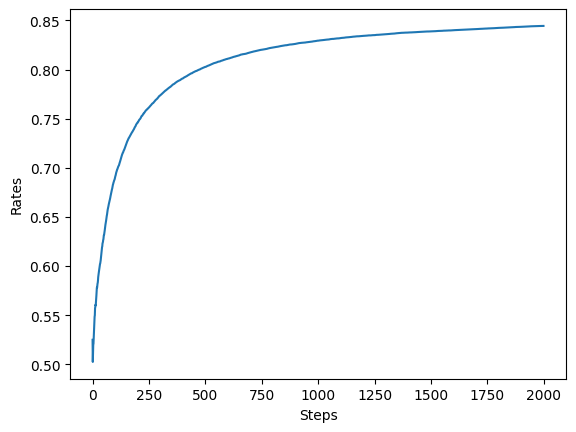

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from a_bandit import Bandit, Agent

runs = 200
steps = 2000
epsilon = 0.1
all_rates = np.zeros((runs, steps))

for run in range(runs):
    bandit = Bandit()
    agent = Agent(epsilon)
    total_reward = 0
    rates = []

    for step in range(steps):
        action = agent.get_action()
        reward = bandit.play(action)
        agent.update(action, reward)
        total_reward += reward
        rates.append(total_reward / (step + 1))

    all_rates[run] = rates

avg_rates = np.average(all_rates, axis=0)

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(avg_rates)
plt.show()

동일한 stationary multi-armed bandit 실험을 여러 번 반복한 결과, 단일 실행에서 나타났던 그래프의 변동성이 평균화되면서 전체적인 성능 경향을 보다 안정적으로 확인할 수 있었다. 즉, 개별 실행에서는 누적 보상 곡선과 평균 승률, 최종 승률 값이 서로 다르게 나타날 수 있지만, 반복 실험을 통해 평균을 계산하면 epsilon-greedy 정책의 전반적인 학습 특성을 더 명확하게 파악할 수 있다.

이는 각 실행마다 슬롯머신의 실제 보상 확률이 무작위로 생성되고, agent의 행동 선택 또한 확률적 요소를 포함하기 때문이다. 따라서 Multi-Armed Bandit 문제의 성능을 보다 신뢰성 있게 해석하기 위해서는 단일 실행 결과만 확인하는 것보다, 여러 번의 반복 실험을 수행한 뒤 평균 성능을 함께 분석하는 것이 더 적절하다고 볼 수 있다.

각 슬롯머신의 승률: [0.43495718 0.57541249 0.60769459 0.18334993 0.96235802 0.2993653
 0.15605083 0.50622282 0.48714696 0.45803385]
가장 좋은 슬롯머신의 승률: 0.9623580227690737

각 슬롯머신의 승률: [0.7907861  0.87334776 0.53629234 0.35300213 0.42197447 0.4330905
 0.3203972  0.12182527 0.47025647 0.32390421]
가장 좋은 슬롯머신의 승률: 0.8733477611210565

각 슬롯머신의 승률: [0.94273178 0.97961963 0.26937611 0.18028503 0.23900916 0.80664501
 0.11143452 0.70652728 0.77937609 0.36087226]
가장 좋은 슬롯머신의 승률: 0.9796196292134614

각 슬롯머신의 승률: [0.78281691 0.81594552 0.88213918 0.22001624 0.12067394 0.53280171
 0.00233506 0.93735741 0.80395237 0.7112496 ]
가장 좋은 슬롯머신의 승률: 0.9373574103219944

각 슬롯머신의 승률: [0.39270538 0.79843292 0.28737745 0.85195033 0.65740606 0.26101813
 0.05354066 0.77680516 0.83001375 0.58195051]
가장 좋은 슬롯머신의 승률: 0.8519503349574609

각 슬롯머신의 승률: [0.65025552 0.38017727 0.33731573 0.92494062 0.2696618  0.92425358
 0.61631284 0.85583848 0.48631285 0.11901634]
가장 좋은 슬롯머신의 승률: 0.9249406196251382

각 슬롯머신의 승률: [0.99029414 0.15528809 0

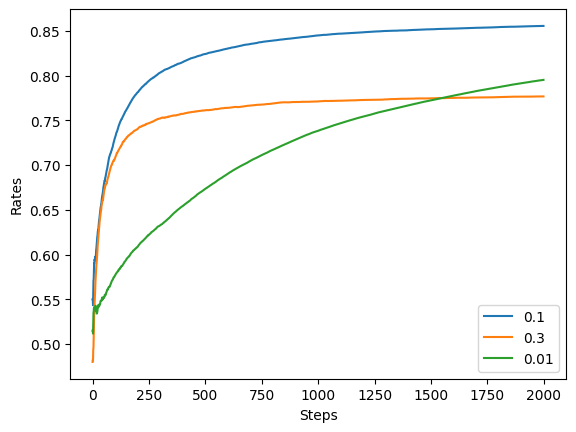

In [29]:
from a_bandit import Bandit, Agent

runs = 200
steps = 2000

for epsilon in [0.1, 0.3, 0.01]:
    all_rates = np.zeros((runs, steps))

    for run in range(runs):
        bandit = Bandit()
        agent = Agent(epsilon)
        total_reward = 0
        rates = []

        for step in range(steps):
            action = agent.get_action()
            reward = bandit.play(action)
            agent.update(action, reward)
            total_reward += reward
            rates.append(total_reward / (step + 1))

        all_rates[run] = rates

    avg_rates = np.average(all_rates, axis=0)
    plt.plot(avg_rates, label=str(epsilon))  # epsilon 값이 범례에 표시됨

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.legend()
plt.show()

## 4. 실습 3: c_non_stationary_bandit_avg.py

non-stationary multi-armed bandit 환경에서는 각 슬롯머신의 보상 확률이 시간에 따라 변한다.
이러한 환경에서 기존의 평균 기반 가치 추정 방식이 어떤 한계를 가지는지 확인하고,
환경 변화에 대한 agent의 적응 특성을 살펴본다.

각 슬롯머신의 승률: [0.52748977 0.01606605 0.31734608 0.96064485 0.50191653 0.65597978
 0.44504892 0.31771079 0.38125399 0.04757778]
가장 좋은 슬롯머신의 승률: 0.9606448527864987

각 슬롯머신의 승률: [0.05264991 0.05507849 0.14829693 0.67301163 0.03198709 0.96448868
 0.03102969 0.50612812 0.24405053 0.45288215]
가장 좋은 슬롯머신의 승률: 0.9644886825892228

각 슬롯머신의 승률: [0.59494439 0.81872829 0.32189759 0.1098319  0.6220624  0.61654814
 0.00616072 0.55778178 0.40646905 0.32750058]
가장 좋은 슬롯머신의 승률: 0.8187282869887993

각 슬롯머신의 승률: [0.43619325 0.74616361 0.28083367 0.56874408 0.03238385 0.30820305
 0.55009397 0.72744546 0.44169186 0.80160979]
가장 좋은 슬롯머신의 승률: 0.8016097871582184

각 슬롯머신의 승률: [0.21512474 0.15474124 0.7118242  0.3430607  0.67822155 0.01389801
 0.78598502 0.59548    0.80949768 0.45593981]
가장 좋은 슬롯머신의 승률: 0.8094976771420413

각 슬롯머신의 승률: [0.76592903 0.1342791  0.98533054 0.53879912 0.77972521 0.9827544
 0.41999462 0.28016636 0.92936878 0.76442826]
가장 좋은 슬롯머신의 승률: 0.985330542722925

각 슬롯머신의 승률: [0.81138631 0.04251864 0

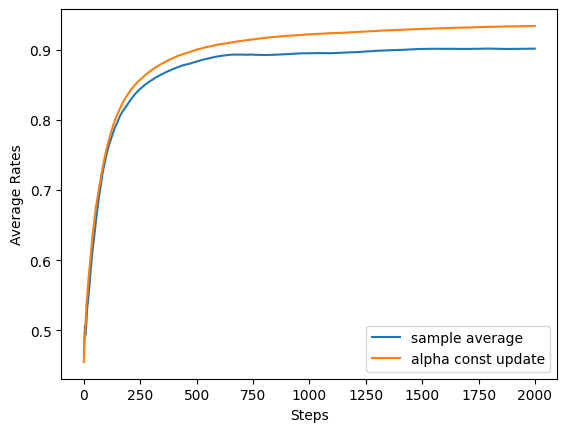

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from a_bandit import Agent


class NonStationaryBandit:
    def __init__(self, arms=10):
        self.arms = arms
        self.rates = np.random.rand(arms)
        print("각 슬롯머신의 승률:", self.rates)
        print("가장 좋은 슬롯머신의 승률:", max(self.rates))
        print()

    def play(self, arm):
        rate = self.rates[arm]
        self.rates += 0.1 * np.random.randn(self.arms)  # 노이즈 추가
        if rate > np.random.rand():
            return 1
        else:
            return 0


class AlphaAgent:
    def __init__(self, epsilon, alpha, action_size=10):
        self.epsilon = epsilon  # 무작위로 행동할 확률(탐색 확률)
        self.Qs = np.zeros(action_size)
        self.alpha = alpha  # 고정값 α

    def update(self, action, reward):
        # α로 갱신
        self.Qs[action] += (reward - self.Qs[action]) * self.alpha

    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))  # 무작위 행동 선택
        return np.argmax(self.Qs)  # 탐욕 행동 선택


runs = 200
steps = 2000
epsilon = 0.1
alpha = 0.8
agent_types = ['sample average', 'alpha const update']
results = {}

for agent_type in agent_types:
    all_rates = np.zeros((runs, steps))  # (200, 1000)

    for run in range(runs):
        if agent_type == 'sample average':
            agent = Agent(epsilon)
        else:
            agent = AlphaAgent(epsilon, alpha)

        bandit = NonStationaryBandit()
        total_reward = 0
        rates = []

        for step in range(steps):
            action = agent.get_action()
            reward = bandit.play(action)
            agent.update(action, reward)
            total_reward += reward
            rates.append(total_reward / (step + 1))

        all_rates[run] = rates

    avg_rates = np.average(all_rates, axis=0)
    results[agent_type] = avg_rates

# [그림 1-20] 표본 평균과 고정값 α에 의한 갱신 비교
plt.figure()
plt.ylabel('Average Rates')
plt.xlabel('Steps')
for key, avg_rates in results.items():
    plt.plot(avg_rates, label=key)
plt.legend()
plt.show()


non-stationary multi-armed bandit 환경에서 두 방식을 비교한 결과, sample average 방식과 alpha const update 방식은 평균 승률 곡선과 최종 성능에서 차이를 보였다. 이는 non-stationary 환경에서는 각 슬롯머신의 보상 확률이 시간에 따라 계속 변하기 때문에, 과거 보상을 동일한 비중으로 반영하는 방식과 최근 보상에 더 큰 가중치를 두는 방식 사이에 적응 속도의 차이가 발생하기 때문이다.

즉, non-stationary multi-armed bandit 문제에서는 단순히 과거 평균을 누적하는 방식보다, 최근 환경 변화를 더 빠르게 반영할 수 있는 업데이트 방식이 더 유리할 수 있다. 따라서 환경이 고정되어 있지 않은 경우에는 sample average 방식의 한계를 고려해야 하며, 성능을 보다 적절하게 해석하기 위해서는 환경 변화에 대한 적응 특성까지 함께 살펴볼 필요가 있다.